In [11]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

In [2]:
# 1. SPATIO-TEMPORAL DATA PIPELINE (Ireland Bounding Box)
def generate_ireland_spatiotemporal_grid(
    num_frames=100, height=32, width=32
):
  """Generates sequential spatial grid data (Channels, Height, Width)

  simulating cloud motion / precipitation over an Ireland spatial grid.
  """
  t = np.linspace(0, 4 * np.pi, num_frames)
  x = np.linspace(-2, 2, width)
  y = np.linspace(-2, 2, height)
  xx, yy = np.meshgrid(x, y)

  frames = []
  for step in t:
    # Gaussian signal representing cloud cover moving across the grid
    grid = np.exp(-((xx - np.sin(step)) ** 2 + (yy - np.cos(step)) ** 2))
    noise = np.random.normal(0, 0.05, grid.shape)
    frames.append(np.clip(grid + noise, 0, 1))

  # Return tensor shape: (Time, Channels, Height, Width)
  return np.array(frames)[:, np.newaxis, :, :]

In [3]:
# 2. TASK 1: CHANGE DETECTION METRICS
def compute_frame_change(frames):
  """Calculates spatial frame-to-frame change metrics over time."""
  # Absolute difference between frame t and frame t-1
  diffs = np.abs(frames[1:] - frames[:-1])
  mean_change_per_frame = diffs.mean(axis=(1, 2, 3))
  return diffs, mean_change_per_frame

In [5]:
# 3. TASK 2: PYTORCH CONVLSTM MODEL & DATASET
class TemporalGridDataset(Dataset):

  def __init__(self, data, sequence_length=4):
    self.data = torch.tensor(data, dtype=torch.float32)
    self.seq_len = sequence_length

  def __len__(self):
    return len(self.data) - self.seq_len

  def __getitem__(self, idx):
    # Input X: Past sequence of length K -> Shape (K, C, H, W)
    x = self.data[idx : idx + self.seq_len]
    # Target Y: Next frame at t+K -> Shape (C, H, W)
    y = self.data[idx + self.seq_len]
    return x, y


class ConvLSTMCell(nn.Module):

  def __init__(self, in_channels, hidden_channels, kernel_size=3):
    super().__init__()
    padding = kernel_size // 2
    self.hidden_channels = hidden_channels
    self.gates = nn.Conv2d(
        in_channels + hidden_channels,
        4 * hidden_channels,
        kernel_size,
        padding=padding,
    )

  def forward(self, x, h, c):
    combined = torch.cat([x, h], dim=1)
    conv_out = self.gates(combined)
    i, f, o, g = torch.chunk(conv_out, 4, dim=1)

    i = torch.sigmoid(i)
    f = torch.sigmoid(f)
    o = torch.sigmoid(o)
    g = torch.tanh(g)

    c_next = f * c + i * g
    h_next = o * torch.tanh(c_next)
    return h_next, c_next


class SpatialTemporalPredictor(nn.Module):

  def __init__(self, in_channels=1, hidden_channels=16):
    super().__init__()
    self.conv_lstm = ConvLSTMCell(in_channels, hidden_channels)
    self.decoder = nn.Conv2d(hidden_channels, 1, kernel_size=1)

  def forward(self, x):
    # Input tensor shape: (Batch, Sequence_Length, Channels, Height, Width)
    b, t, c, h, w = x.shape
    h_t = torch.zeros(
        b, self.conv_lstm.hidden_channels, h, w, device=x.device
    )
    c_t = torch.zeros(
        b, self.conv_lstm.hidden_channels, h, w, device=x.device
    )

    for time_step in range(t):
      h_t, c_t = self.conv_lstm(x[:, time_step], h_t, c_t)

    # Decode hidden state to output prediction frame at t+1
    out = self.decoder(h_t)
    return out

In [6]:
# 4. EXECUTION PIPELINE
if __name__ == "__main__":
  # Generate spatio-temporal spatial array
  raw_data = generate_ireland_spatiotemporal_grid(
      num_frames=100, height=32, width=32
  )

  # Task 1: Change Detection
  diff_map, mean_changes = compute_frame_change(raw_data)
  print(
      f"--- TASK 1 COMPLETE ---\nEvaluated spatial changes across"
      f" {len(diff_map)} frame pairs."
  )
  print(f"Mean frame-to-frame change intensity: {mean_changes.mean():.4f}\n")

  # Task 2: PyTorch DL Model Training
  print("--- TASK 2: TRAINING PYTORCH MODEL ---")
  dataset = TemporalGridDataset(raw_data, sequence_length=4)
  dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

  model = SpatialTemporalPredictor(in_channels=1, hidden_channels=16)
  criterion = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

  model.train()
  for epoch in range(5):
    total_loss = 0.0
    for x_batch, y_batch in dataloader:
      optimizer.zero_grad()
      predictions = model(x_batch)
      loss = criterion(predictions, y_batch)
      loss.backward()
      optimizer.step()
      total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/5 - Loss (MSE): {avg_loss:.6f}")

--- TASK 1 COMPLETE ---
Evaluated spatial changes across 99 frame pairs.
Mean frame-to-frame change intensity: 0.0512

--- TASK 2: TRAINING PYTORCH MODEL ---
Epoch 1/5 - Loss (MSE): 0.146554
Epoch 2/5 - Loss (MSE): 0.047881
Epoch 3/5 - Loss (MSE): 0.018124
Epoch 4/5 - Loss (MSE): 0.012734
Epoch 5/5 - Loss (MSE): 0.011936


In [7]:
def evaluate_against_persistence(model, dataloader, criterion=nn.MSELoss()):
  model.eval()

  total_model_loss = 0.0
  total_persistence_loss = 0.0
  total_samples = 0

  with torch.no_grad():
    for x_batch, y_batch in dataloader:
      # x_batch shape: (Batch, Sequence_Length, Channels, Height, Width)
      # y_batch shape: (Batch, Channels, Height, Width) or (Batch, 1, Height, Width)

      # 1. Model Prediction
      y_pred_model = model(x_batch)
      model_loss = criterion(y_pred_model, y_batch)

      # 2. Persistence Prediction: Take the last frame of the input sequence
      # x_batch[:, -1] gets frame at index t
      y_pred_persistence = x_batch[:, -1, :, :, :]
      persistence_loss = criterion(y_pred_persistence, y_batch)

      batch_size = x_batch.size(0)
      total_model_loss += model_loss.item() * batch_size
      total_persistence_loss += persistence_loss.item() * batch_size
      total_samples += batch_size

  avg_model_mse = total_model_loss / total_samples
  avg_persistence_mse = total_persistence_loss / total_samples

  # Compute percentage improvement over baseline
  improvement = (
      (avg_persistence_mse - avg_model_mse) / avg_persistence_mse
  ) * 100

  print("--- BENCHMARK RESULTS ---")
  print(f"Persistence Baseline MSE : {avg_persistence_mse:.6f}")
  print(f"ConvLSTM Model MSE       : {avg_model_mse:.6f}")
  print(f"Model Improvement        : {improvement:+.2f}%")

  return avg_persistence_mse, avg_model_mse

In [10]:
def plot_persistence_comparison(x_seq, y_true, y_pred_model):
  """Plots visual comparison between Persistence, Model, and Ground Truth.

  x_seq: (Seq_Len, Height, Width)
  y_true: (Height, Width)
  y_pred_model: (Height, Width)
  """
  last_frame = x_seq[-1]  # Persistence prediction

  persistence_error = np.abs(last_frame - y_true)
  model_error = np.abs(y_pred_model - y_true)

  fig, axes = plt.subplots(2, 3, figsize=(12, 8))

  # Top Row: Predictions
  axes[0, 0].imshow(last_frame, cmap='gist_gray')
  axes[0, 0].set_title('Persistence Input (\(X_t\))')

  axes[0, 1].imshow(y_pred_model, cmap='gist_gray')
  axes[0, 1].set_title('ConvLSTM Prediction (\(\hat{Y}_{t+1}\))')

  axes[0, 2].imshow(y_true, cmap='gist_gray')
  axes[0, 2].set_title('Ground Truth (\(Y_{t+1}\))')

  # Bottom Row: Error Maps
  im1 = axes[1, 0].imshow(persistence_error, cmap='inferno')
  axes[1, 0].set_title('Persistence Abs Error')
  plt.colorbar(im1, ax=axes[1, 0])

  im2 = axes[1, 1].imshow(model_error, cmap='inferno')
  axes[1, 1].set_title('ConvLSTM Abs Error')
  plt.colorbar(im2, ax=axes[1, 1])

  axes[1, 2].axis('off')  # Empty spot for clean layout

  for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

  plt.tight_layout()
  plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\('
<>:20: SyntaxWarning: invalid escape sequence '\('
<>:23: SyntaxWarning: invalid escape sequence '\('
<>:17: SyntaxWarning: invalid escape sequence '\('
<>:20: SyntaxWarning: invalid escape sequence '\('
<>:23: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_105661/3423384489.py:17: SyntaxWarning: invalid escape sequence '\('
  axes[0, 0].set_title('Persistence Input (\(X_t\))')
/tmp/ipykernel_105661/3423384489.py:20: SyntaxWarning: invalid escape sequence '\('
  axes[0, 1].set_title('ConvLSTM Prediction (\(\hat{Y}_{t+1}\))')
/tmp/ipykernel_105661/3423384489.py:23: SyntaxWarning: invalid escape sequence '\('
  axes[0, 2].set_title('Ground Truth (\(Y_{t+1}\))')


<>:26: SyntaxWarning: invalid escape sequence '\('
<>:31: SyntaxWarning: invalid escape sequence '\('
<>:36: SyntaxWarning: invalid escape sequence '\('
<>:26: SyntaxWarning: invalid escape sequence '\('
<>:31: SyntaxWarning: invalid escape sequence '\('
<>:36: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_105661/3563747796.py:26: SyntaxWarning: invalid escape sequence '\('
  axes[0].set_title(f'Frame \(t-1\) (Idx {frame_idx-1})')
/tmp/ipykernel_105661/3563747796.py:31: SyntaxWarning: invalid escape sequence '\('
  axes[1].set_title(f'Frame \(t\) (Idx {frame_idx})')
/tmp/ipykernel_105661/3563747796.py:36: SyntaxWarning: invalid escape sequence '\('
  axes[2].set_title('Absolute Difference Map (\(\Delta I\))')


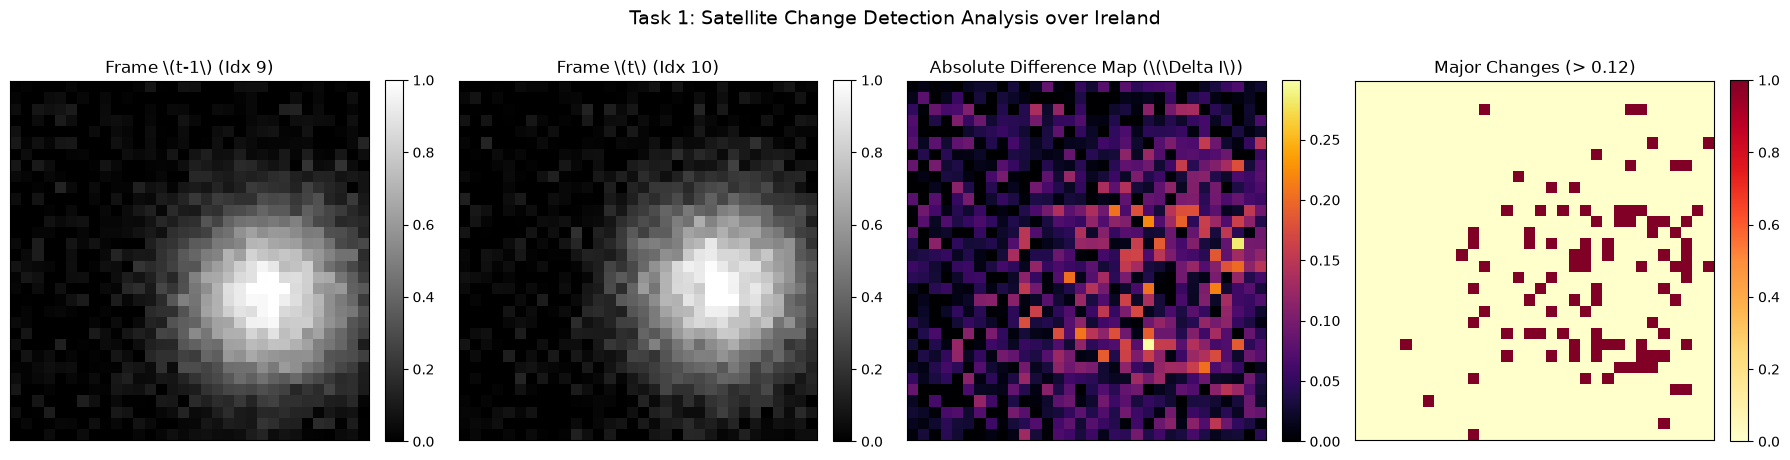

In [12]:
def plot_task1_change_detection(frames, frame_idx=10, threshold=0.15):
    """
    Visualizes Task 1 change detection between frame t-1 and frame t.
    
    frames: NumPy array of shape (Time, Channels, Height, Width) or (Time, Height, Width)
    frame_idx: Index of the current frame to inspect
    threshold: Sensitivity threshold for highlighting significant changes
    """
    # Ensure 2D spatial dimensions (Height, Width)
    if frames.ndim == 4:
        img_prev = frames[frame_idx - 1, 0]
        img_curr = frames[frame_idx, 0]
    else:
        img_prev = frames[frame_idx - 1]
        img_curr = frames[frame_idx]

    # Compute spatial changes
    diff = np.abs(img_curr - img_prev)
    change_mask = diff > threshold  # Binary mask for major changes

    # Setup 4-panel figure
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

    # Panel 1: Previous Frame (t-1)
    im0 = axes[0].imshow(img_prev, cmap='gist_gray', vmin=0, vmax=1)
    axes[0].set_title(f'Frame \(t-1\) (Idx {frame_idx-1})')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    # Panel 2: Current Frame (t)
    im1 = axes[1].imshow(img_curr, cmap='gist_gray', vmin=0, vmax=1)
    axes[1].set_title(f'Frame \(t\) (Idx {frame_idx})')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    # Panel 3: Absolute Spatial Difference Map
    im2 = axes[2].imshow(diff, cmap='inferno')
    axes[2].set_title('Absolute Difference Map (\(\Delta I\))')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    # Panel 4: Significant Change Mask
    im3 = axes[3].imshow(change_mask, cmap='YlOrRd')
    axes[3].set_title(f'Major Changes (> {threshold})')
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle("Task 1: Satellite Change Detection Analysis over Ireland", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Run visualization on frame index 10
plot_task1_change_detection(raw_data, frame_idx=10, threshold=0.12)

<>:18: SyntaxWarning: invalid escape sequence '\('
<>:19: SyntaxWarning: invalid escape sequence '\('
<>:18: SyntaxWarning: invalid escape sequence '\('
<>:19: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_105661/3684510261.py:18: SyntaxWarning: invalid escape sequence '\('
  plt.xlabel('Frame Time Step (\(t\))')
/tmp/ipykernel_105661/3684510261.py:19: SyntaxWarning: invalid escape sequence '\('
  plt.ylabel('Mean Absolute Pixel Change (\(\Delta I\))')


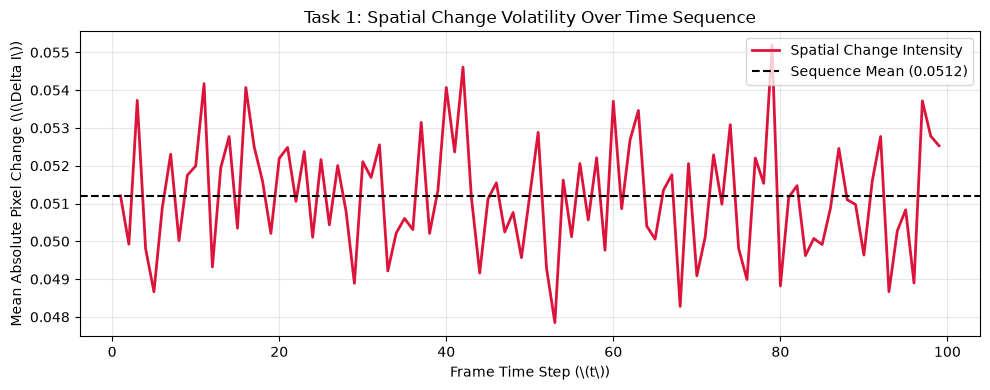

In [13]:
def plot_temporal_activity(frames):
    """
    Plots overall atmospheric activity across the full time series.
    """
    if frames.ndim == 4:
        diffs = np.abs(frames[1:, 0] - frames[:-1, 0])
    else:
        diffs = np.abs(frames[1:] - frames[:-1])
        
    mean_activity = diffs.mean(axis=(1, 2))
    time_steps = np.arange(1, len(frames))

    plt.figure(figsize=(10, 4))
    plt.plot(time_steps, mean_activity, color='crimson', linewidth=2, label='Spatial Change Intensity')
    plt.axhline(mean_activity.mean(), color='black', linestyle='--', label=f'Sequence Mean ({mean_activity.mean():.4f})')
    
    plt.title('Task 1: Spatial Change Volatility Over Time Sequence')
    plt.xlabel('Frame Time Step (\(t\))')
    plt.ylabel('Mean Absolute Pixel Change (\(\Delta I\))')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_temporal_activity(raw_data)